In [1]:
import pandas as pd

# Read csv
raw = pd.read_csv("climbing injuries.csv")

# Keep only rows where Respondent ID is numeric, because it includes the real data rows (header row + Total are non-numeric)
mask_numeric_id = pd.to_numeric(raw["Respondent ID"], errors="coerce").notna()
df = raw.loc[mask_numeric_id].copy()

# Drop unnecessary columns
cols_to_drop = [
    "Respondent ID",
    "Collector ID",
    "Start Date",
    "End Date",
    "IP Address",
    "Email Address",
    "First Name",
    "Last Name",
    "Custom Data 1",
]
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

# Find the exact surgery-description column (it has a strange space character)
surgery_desc_col = [c for c in df.columns if "What surgery did you require?" in c][0]

# Columns to keep (same as before)
keep_cols = [
    # Age
    "What is your age?", "Unnamed: 10", "Unnamed: 11",
    "Unnamed: 12", "Unnamed: 13", "Unnamed: 14",

    # Sex
    "Birth Sex?", "Unnamed: 16",

    # Years climbing
    "How many years have you climbed?",
    "Unnamed: 18", "Unnamed: 19", "Unnamed: 20",
    "Unnamed: 21", "Unnamed: 22",

    # Rope grades
    "What grade do you consider you climb?",
    "Unnamed: 24", "Unnamed: 25", "Unnamed: 26",
    "Unnamed: 27", "Unnamed: 28",

    # Boulder grades
    "What grade do you consider you boulder?",
    "Unnamed: 30", "Unnamed: 31", "Unnamed: 32",
    "Unnamed: 33", "Unnamed: 34",

    # Injuries
    "Have you had any climbing injuries? (check all that apply)",
    "Unnamed: 36", "Unnamed: 37", "Unnamed: 38",
    "Unnamed: 39", "Unnamed: 40", "Unnamed: 41",
    "Please list your injury.",

    # Recovery time options
    "How long did the whole recovery process take before you were climbing at your same grade or better?",
    "Unnamed: 44", "Unnamed: 45", "Unnamed: 46",
    "Unnamed: 47", "Unnamed: 48", "Unnamed: 49", "Unnamed: 50",

    # Surgery / PT
    "Did you require surgery? And are you satisfied with the surgery?",
    "Unnamed: 52", "Unnamed: 53", "Unnamed: 54", "Unnamed: 55",

    # Surgery description
    surgery_desc_col,
]

df = df[keep_cols].copy()

# Rename columns to be easier to read
rename_dict = {
    # Age buckets
    "What is your age?": "age_0_18",
    "Unnamed: 10": "age_19_26",
    "Unnamed: 11": "age_27_35",
    "Unnamed: 12": "age_36_45",
    "Unnamed: 13": "age_46_60",
    "Unnamed: 14": "age_61_plus",

    # Sex
    "Birth Sex?": "sex_male",
    "Unnamed: 16": "sex_female",

    # Years climbing
    "How many years have you climbed?": "years_0_1",
    "Unnamed: 18": "years_2_3",
    "Unnamed: 19": "years_4_5",
    "Unnamed: 20": "years_6_8",
    "Unnamed: 21": "years_9_15",
    "Unnamed: 22": "years_15_plus",

    # Rope grades
    "What grade do you consider you climb?": "route_59_or_less",
    "Unnamed: 24": "route_510a_511a",
    "Unnamed: 25": "route_511b_511d",
    "Unnamed: 26": "route_512a_512d",
    "Unnamed: 27": "route_513a_513d",
    "Unnamed: 28": "route_514_plus",

    # Boulder grades
    "What grade do you consider you boulder?": "boulder_V3_or_less",
    "Unnamed: 30": "boulder_V4_V5",
    "Unnamed: 31": "boulder_V6_V7",
    "Unnamed: 32": "boulder_V8_V9",
    "Unnamed: 33": "boulder_V10_V12",
    "Unnamed: 34": "boulder_V13_plus",

    # Injury categories
    "Have you had any climbing injuries? (check all that apply)": "injury_hand_elbow",
    "Unnamed: 36": "injury_shoulder",
    "Unnamed: 37": "injury_spine",
    "Unnamed: 38": "injury_pelvis_hip",
    "Unnamed: 39": "injury_knee",
    "Unnamed: 40": "injury_foot_ankle",
    "Unnamed: 41": "injury_other",

    "Please list your injury.": "injury_description",

    # Recovery options (multi-choice)
    "How long did the whole recovery process take before you were climbing at your same grade or better?": "recovery_less_1_month",
    "Unnamed: 44": "recovery_1_2_months",
    "Unnamed: 45": "recovery_2_6_months",
    "Unnamed: 46": "recovery_6_12_months",
    "Unnamed: 47": "recovery_1_2_years",
    "Unnamed: 48": "recovery_2_5_years",
    "Unnamed: 49": "recovery_never_recovered_worse",
    "Unnamed: 50": "recovery_still_recovering",

    # Surgery choices
    "Did you require surgery? And are you satisfied with the surgery?": "surgery_yes_satisfied",
    "Unnamed: 52": "surgery_yes_not_satisfied",
    "Unnamed: 53": "surgery_no",
    "Unnamed: 54": "surgery_no_but_PT",
    "Unnamed: 55": "surgery_other",

    # Surgery text
    surgery_desc_col: "surgery_description",
}

df_clean = df.rename(columns=rename_dict).reset_index(drop=True)

# Checkbox-style columns (not free-text description)
binary_cols = [
    c for c in df_clean.columns
    if (
        c.startswith(("age_", "sex_", "years_", "route_", "boulder_",
                      "injury_", "recovery_", "surgery_"))
        and not c.endswith("_description")
    )
]

# Any non-NaN value -> 1, NaN -> 0
df_clean[binary_cols] = df_clean[binary_cols].notna().astype(int)

print(df_clean[binary_cols].head(5))


   age_0_18  age_19_26  age_27_35  age_36_45  age_46_60  age_61_plus  \
0         0          0          1          0          0            0   
1         0          0          0          1          0            0   
2         0          0          1          0          0            0   
3         0          0          0          1          0            0   
4         0          0          1          0          0            0   

   sex_male  sex_female  years_0_1  years_2_3  ...  recovery_6_12_months  \
0         1           0          0          0  ...                     0   
1         1           0          0          0  ...                     0   
2         0           1          0          0  ...                     0   
3         0           1          0          0  ...                     0   
4         1           0          0          0  ...                     1   

   recovery_1_2_years  recovery_2_5_years  recovery_never_recovered_worse  \
0                   0            

In [2]:
# observations in the cleaned dataset?
df_clean.shape[0]

rows, cols = df_clean.shape
print("Rows (observations):", rows)
print("Columns (features):", cols)


Rows (observations): 237
Columns (features): 48


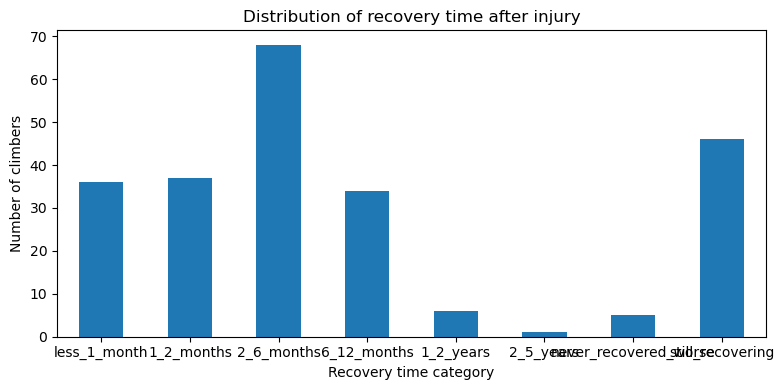

In [3]:
import matplotlib.pyplot as plt

# Create a single categorical variable for recovery
recovery_cols = [c for c in df_clean.columns if c.startswith("recovery_")]
recovery_any = df_clean[recovery_cols].any(axis=1)
recovery_cat = (
    df_clean.loc[recovery_any, recovery_cols]
    .idxmax(axis=1)                # column name with 1
    .str.replace("recovery_", "")  # nicer label
)

# Order categories if you like
order = [
    "less_1_month",
    "1_2_months",
    "2_6_months",
    "6_12_months",
    "1_2_years",
    "2_5_years",
    "never_recovered_worse",
    "still_recovering",
]

counts = recovery_cat.value_counts().reindex(order)

plt.figure(figsize=(8, 4))
counts.plot(kind="bar")
plt.ylabel("Number of climbers")
plt.xlabel("Recovery time category")
plt.title("Distribution of recovery time after injury")
plt.xticks(rotation=0, ha="center")
plt.tight_layout()
plt.show()


<Figure size 800x400 with 0 Axes>

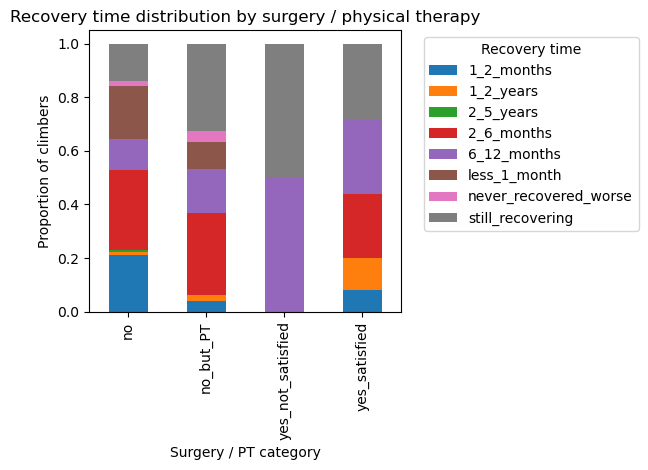

In [4]:
# Build a single categorical variable for surgery/PT
surgery_cols = [
    c for c in df_clean.columns
    if c.startswith("surgery_") and not c.endswith("_description")
]

surg_any = df_clean[surgery_cols].any(axis=1)

surgery_cat = (
    df_clean.loc[surg_any, surgery_cols]
    .idxmax(axis=1)                 # column name that has value 1
    .str.replace("surgery_", "")    # nicer label
)


# Use the same recovery_cat as above (make sure to run that code first)
tmp = df_clean.loc[recovery_any & surg_any, :].copy()
tmp["recovery_cat"] = recovery_cat[recovery_any & surg_any].values
tmp["surgery_cat"] = surgery_cat[recovery_any & surg_any].values

# Simple grouped bar: proportion of each recovery category within each surgery group
prop_table = (
    tmp.pivot_table(index="recovery_cat", columns="surgery_cat",
                    aggfunc="size", fill_value=0)
)
prop_table = prop_table.div(prop_table.sum(axis=0), axis=1)  # normalize by column

plt.figure(figsize=(8, 4))
prop_table.T.plot(kind="bar", stacked=True)
plt.ylabel("Proportion of climbers")
plt.xlabel("Surgery / PT category")
plt.title("Recovery time distribution by surgery / physical therapy")
plt.legend(title="Recovery time", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.xticks(rotation=90, ha="center")
plt.tight_layout()
plt.show()


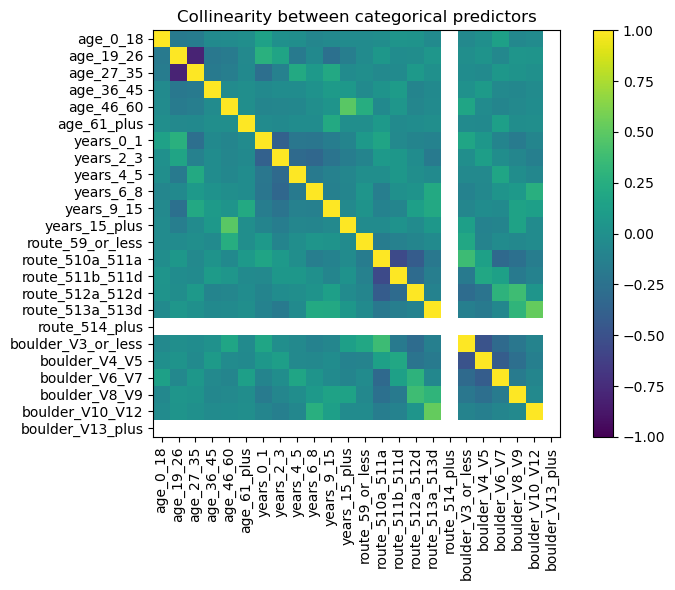

In [5]:
subset_cols = [
    *[c for c in df_clean.columns if c.startswith("age_")],
    *[c for c in df_clean.columns if c.startswith("years_")],
    *[c for c in df_clean.columns if c.startswith("route_")],
    *[c for c in df_clean.columns if c.startswith("boulder_")],
]

corr = df_clean[subset_cols].corr()

plt.figure(figsize=(8, 6))
plt.imshow(corr, vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(subset_cols)), subset_cols, rotation=90)
plt.yticks(range(len(subset_cols)), subset_cols)
plt.title("Collinearity between categorical predictors")
plt.tight_layout()
plt.show()


Recovery_group3 counts (including NaN):
recovery_group3
short     141
long       52
medium     40
<NA>        4
Name: count, dtype: int64

X shape: (233, 38)
y value counts:
recovery_group3
short     141
long       52
medium     40
Name: count, dtype: int64

=== Logistic Regression (3-group: short / medium / long) ===
Accuracy: 0.5957446808510638
F1 (macro): 0.39375
F1 (weighted): 0.550531914893617

Classification report:
              precision    recall  f1-score   support

       short       0.69      0.89      0.78        28
      medium       0.14      0.12      0.13         8
        long       0.50      0.18      0.27        11

    accuracy                           0.60        47
   macro avg       0.45      0.40      0.39        47
weighted avg       0.56      0.60      0.55        47

Confusion matrix (rows = true, cols = predicted):
             pred_short  pred_medium  pred_long
true_short           25            3          0
true_medium           5            1          2

<Figure size 500x400 with 0 Axes>

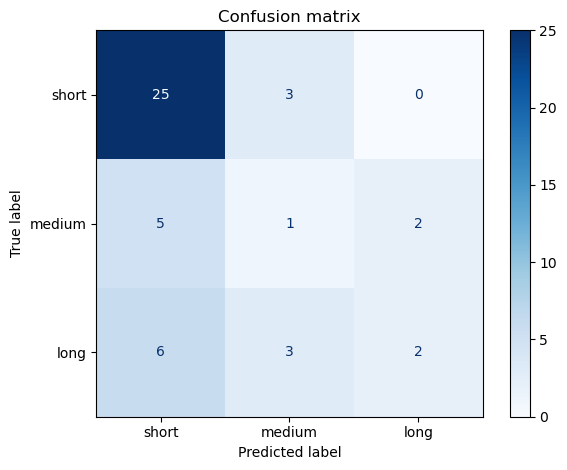

In [6]:
# ============================
# 1) Build target: short / medium / long
# ============================

# We already have:
# - recovery_cols
# - recovery_any
# - recovery_cat  (values like "less_1_month", "1_2_months", ...)

# Map the 8 detailed categories into 3 groups
recovery_to_group = {
    "less_1_month":           "short",
    "1_2_months":             "short",
    "2_6_months":             "short",
    "6_12_months":            "medium",
    "1_2_years":              "medium",
    "2_5_years":              "long",
    "never_recovered_worse":  "long",
    "still_recovering":       "long",
}

# Create a new column in df_clean with 3 recovery groups
df_clean["recovery_group3"] = pd.NA
df_clean.loc[recovery_any, "recovery_group3"] = recovery_cat.map(recovery_to_group)

print("Recovery_group3 counts (including NaN):")
print(df_clean["recovery_group3"].value_counts(dropna=False))
print()

# ============================
# 2) Build X (features) and y (target) for logistic regression
# ============================

# Use all binary predictors EXCEPT the original recovery_* columns (avoid data leakage)
feature_cols = [c for c in binary_cols if not c.startswith("recovery_")]

# Keep only rows that have a defined recovery group (short/medium/long)
mask = df_clean["recovery_group3"].notna()
X = df_clean.loc[mask, feature_cols]
y = df_clean.loc[mask, "recovery_group3"]

print("X shape:", X.shape)
print("y value counts:")
print(y.value_counts())
print()

# ============================
# 3) Train / test split
# ============================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,   # keep class proportions in train & test
)

# ============================
# 4) Fit multinomial logistic regression
# ============================

from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    max_iter=1000,
    multi_class="multinomial",   # softmax for multi-class
    solver="lbfgs"
)

log_reg.fit(X_train, y_train)

# ============================
# 5) Predictions + metrics + confusion matrix
# ============================

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

y_pred = log_reg.predict(X_test)

labels = ["short", "medium", "long"]   # order of classes

print("=== Logistic Regression (3-group: short / medium / long) ===")

# Accuracy & F1
acc = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average="macro")
f1_weighted = f1_score(y_test, y_pred, average="weighted")

print(f"Accuracy: {acc}")
print(f"F1 (macro): {f1_macro}")
print(f"F1 (weighted): {f1_weighted}")
print()

# Classification report (giống format bạn chụp màn hình)
print("Classification report:")
print(classification_report(y_test, y_pred, labels=labels, target_names=labels))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=labels)
print("Confusion matrix (rows = true, cols = predicted):")
print(pd.DataFrame(
    cm,
    index=[f"true_{l}" for l in labels],
    columns=[f"pred_{l}" for l in labels],
))

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
plt.figure(figsize=(5, 4))
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion matrix")
plt.tight_layout()
plt.show()


AUC by class:
short: AUC = 0.324
medium: AUC = 0.606
long: AUC = 0.443


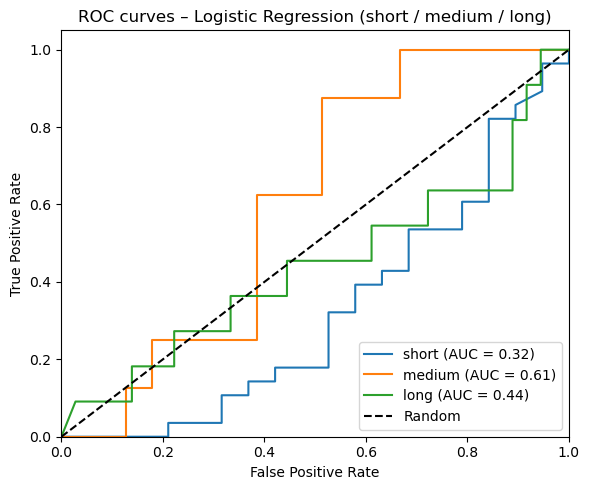

In [7]:
# ============================
# 6) Multi-class ROC (one-vs-rest)
# ============================
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

labels = ["short", "medium", "long"]

# Binarize y_test: each column is one class (short / medium / long)
y_test_bin = label_binarize(y_test, classes=labels)   # shape (n_samples, 3)

# Predicted probabilities for each class from logistic regression
y_score = log_reg.predict_proba(X_test)               # shape (n_samples, 3)

# Compute ROC and AUC 
fpr = dict()
tpr = dict()
roc_auc = dict()

for i, cls in enumerate(labels):
    fpr[cls], tpr[cls], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[cls] = auc(fpr[cls], tpr[cls])

print("AUC by class:")
for cls in labels:
    print(f"{cls}: AUC = {roc_auc[cls]:.3f}")

# Plot all ROC curves on the same figure
plt.figure(figsize=(6, 5))
for cls in labels:
    plt.plot(fpr[cls], tpr[cls], label=f"{cls} (AUC = {roc_auc[cls]:.2f})")

plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curves – Logistic Regression (short / medium / long)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Classes in the order used by the model
print("Classes:", log_reg.classes_)

feature_names = X_train.columns

# Coefficient matrix: shape = (n_classes, n_features)
coef_matrix = pd.DataFrame(
    log_reg.coef_,
    index=log_reg.classes_,   # rows = classes
    columns=feature_names     # cols = features
).T                           # transpose → rows = features, cols = classes

print(coef_matrix.head())


Classes: ['long' 'medium' 'short']
               long    medium     short
age_0_18  -0.123547 -0.282347  0.405894
age_19_26 -0.743458  0.286765  0.456693
age_27_35 -0.017140  0.183855 -0.166715
age_36_45  0.568521 -0.361737 -0.206784
age_46_60 -0.040527  0.212813 -0.172286


In [9]:
# Max |coefficient| over all classes → importance
coef_matrix["max_abs_coef"] = coef_matrix.abs().max(axis=1)

# Sort from most important to least important
feat_imp = coef_matrix.sort_values("max_abs_coef", ascending=False)

print(feat_imp[["max_abs_coef"]].head(15))


                           max_abs_coef
injury_pelvis_hip              0.815220
age_19_26                      0.743458
injury_spine                   0.705222
surgery_no                     0.693266
years_0_1                      0.624957
age_36_45                      0.568521
injury_hand_elbow              0.523399
injury_shoulder                0.512261
route_513a_513d                0.503884
surgery_yes_satisfied          0.479385
surgery_yes_not_satisfied      0.438995
age_0_18                       0.405894
years_2_3                      0.402793
route_510a_511a                0.368776
surgery_no_but_PT              0.361550


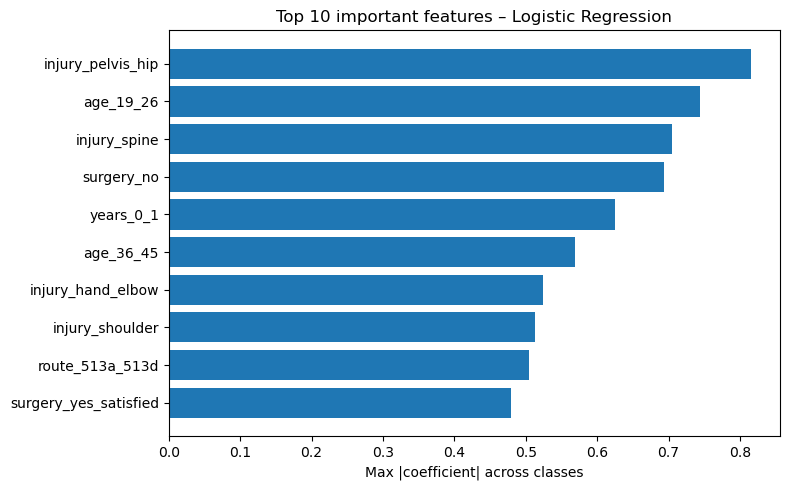

In [10]:
top_k = 10
top_feats = feat_imp.head(top_k)

plt.figure(figsize=(8, 5))
plt.barh(top_feats.index, top_feats["max_abs_coef"])
plt.xlabel("Max |coefficient| across classes")
plt.title("Top {} important features – Logistic Regression".format(top_k))
plt.gca().invert_yaxis()  
plt.tight_layout()
plt.show()
